# 📊 Phase 3 — Advanced Data Analysis
### Retail Sales Analytics | Internship Studio
---
**What this notebook covers:**
- 3.1 Setup & Data Load
- 3.2 Exploratory Data Analysis (EDA)
- 3.3 RFM Customer Segmentation
- 3.4 Time-Series & Trend Analysis
- 3.5 Cohort Retention Analysis
- 3.6 Response Rate Deep-Dive
- 3.7 Key Insights Summary


## 3.1  Setup & Data Load

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import sqlite3, warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 130, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.family': 'DejaVu Sans'})
sns.set_palette("husl")

# ── Load cleaned data ─────────────────────────────────────────────────────
# Option A: from cleaned CSV
df = pd.read_csv(r"D:\Istudio\Retail-Sales-Analytics\data\processed\cleaned_retail_data.csv", parse_dates=['trans_date'])

# Option B: from SQLite (uncomment if using DB)
# conn = sqlite3.connect('retail_sales.db')
# df   = pd.read_sql('SELECT * FROM retail_sales', conn, parse_dates=['trans_date'])

print(f"Rows: {len(df):,}  |  Columns: {df.columns.tolist()}")
df.head()


Rows: 124,969  |  Columns: ['customer_id', 'trans_date', 'tran_amount', 'response', 'month', 'year', 'day', 'month_year', 'Segment']


,customer_id,trans_date,tran_amount,response,month,year,day,month_year,Segment
0,CS5295,2013-02-11,35,1,2,2013,11,2013-02,High Value
1,CS4768,2015-03-15,39,1,3,2015,15,2015-03,High Value
2,CS2122,2013-02-26,52,0,2,2013,26,2013-02,High Value
3,CS1217,2011-11-16,99,0,11,2011,16,2011-11,High Value
4,CS1850,2013-11-20,78,0,11,2013,20,2013-11,High Value


## 3.2  Exploratory Data Analysis (EDA)

In [5]:
# ── Summary statistics ────────────────────────────────────────────────────
print("=== Dataset Overview ===")
print(f"Date range  : {df['trans_date'].min().date()} → {df['trans_date'].max().date()}")
print(f"Customers   : {df['customer_id'].nunique():,}")
print(f"Transactions: {len(df):,}")
print(f"Total Rev   : ${df['tran_amount'].sum():,.0f}")
print(f"Avg Txn     : ${df['tran_amount'].mean():.2f}")
print()
df['tran_amount'].describe().round(2)


=== Dataset Overview ===
Date range  : 2011-05-16 → 2015-03-16
Customers   : 6,884
Transactions: 124,969
Total Rev   : $8,122,378
Avg Txn     : $65.00



count    124969.00
mean         65.00
std          22.86
min          10.00
25%          47.00
50%          65.00
75%          83.00
max         105.00
Name: tran_amount, dtype: float64

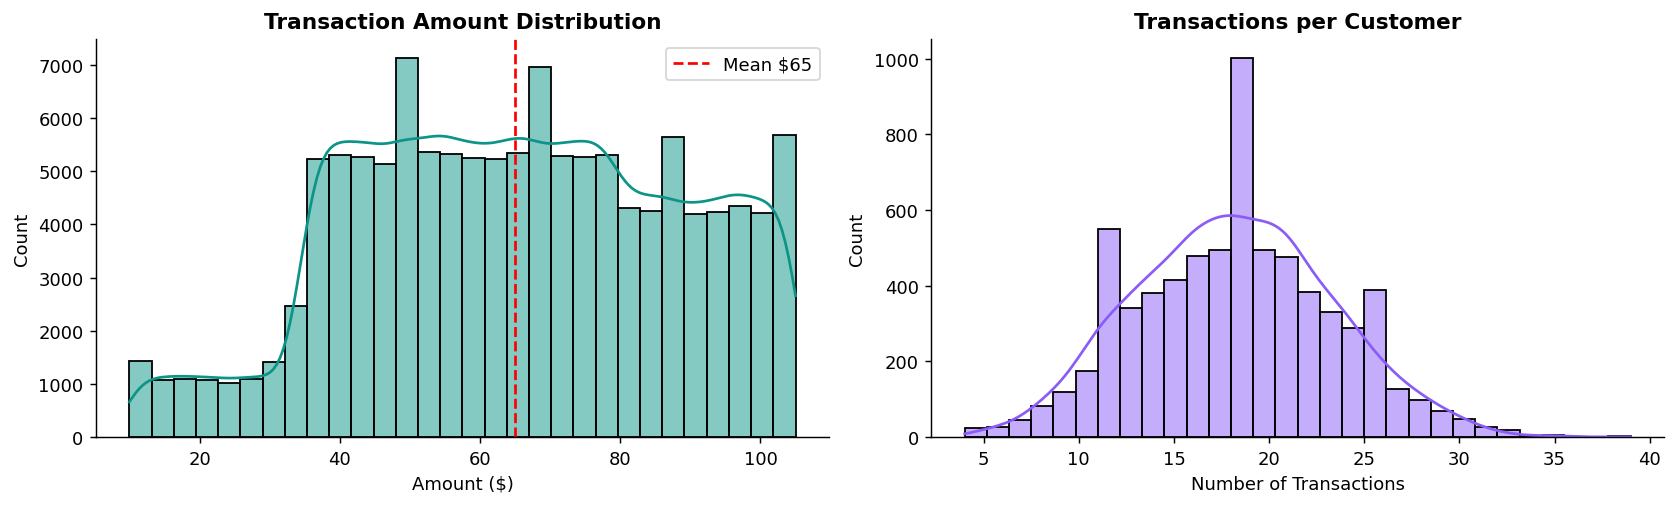

Median txns per customer: 18


In [9]:
# ── Distribution plots ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(df['tran_amount'], bins=30, kde=True, ax=axes[0], color='#0D9488')
axes[0].set_title('Transaction Amount Distribution', fontweight='bold')
axes[0].set_xlabel('Amount ($)')
axes[0].axvline(df['tran_amount'].mean(), color='red', linestyle='--', label=f"Mean ${df['tran_amount'].mean():.0f}")
axes[0].legend()

txn_per_customer = df.groupby('customer_id')['tran_amount'].count()
sns.histplot(txn_per_customer, bins=30, kde=True, ax=axes[1], color='#8B5CF6')
axes[1].set_title('Transactions per Customer', fontweight='bold')
axes[1].set_xlabel('Number of Transactions')

plt.tight_layout()
plt.savefig('../reports/charts/eda_distributions.png', bbox_inches='tight')
plt.show()
print(f"Median txns per customer: {txn_per_customer.median():.0f}")


## 3.3  RFM Customer Segmentation

In [10]:
# ── Build RFM table ───────────────────────────────────────────────────────
snapshot_date = df['trans_date'].max() + pd.Timedelta(days=1)

rfm = df.groupby('customer_id').agg(
    recency   = ('trans_date',  lambda x: (snapshot_date - x.max()).days),
    frequency = ('trans_date',  'count'),
    monetary  = ('tran_amount', 'sum')
).reset_index()

# Score 1-4 (4 = best)
rfm['R'] = pd.qcut(rfm['recency'],   4, labels=[4,3,2,1]).astype(int)
rfm['F'] = pd.qcut(rfm['frequency'].rank(method='first'), 4, labels=[1,2,3,4]).astype(int)
rfm['M'] = pd.qcut(rfm['monetary'],  4, labels=[1,2,3,4]).astype(int)
rfm['RFM_Score'] = rfm['R'] + rfm['F'] + rfm['M']

def label_segment(s):
    if s >= 10: return 'Champions'
    elif s >= 7: return 'Loyal'
    elif s >= 5: return 'At Risk'
    else:        return 'Lost'

rfm['Segment'] = rfm['RFM_Score'].apply(label_segment)

print(rfm['Segment'].value_counts())
rfm.describe().round(2)


Segment
Loyal        2403
Champions    1879
At Risk      1518
Lost         1084
Name: count, dtype: int64


,recency,frequency,monetary,R,F,M,RFM_Score
count,6884.00,6884.00,6884.00,6884.00,6884.00,6884.00,6884.00
mean,81.02,18.15,1179.89,2.51,2.50,2.50,7.51
std,83.25,5.18,465.42,1.12,1.12,1.12,2.64
min,1.00,4.00,149.00,1.00,1.00,1.00,3.00
25%,23.00,14.00,781.00,2.00,1.75,1.00,5.00
50%,54.00,18.00,1228.00,3.00,2.50,2.00,8.00
75%,112.00,22.00,1520.25,4.00,3.25,3.25,10.00
max,679.00,39.00,2933.00,4.00,4.00,4.00,12.00


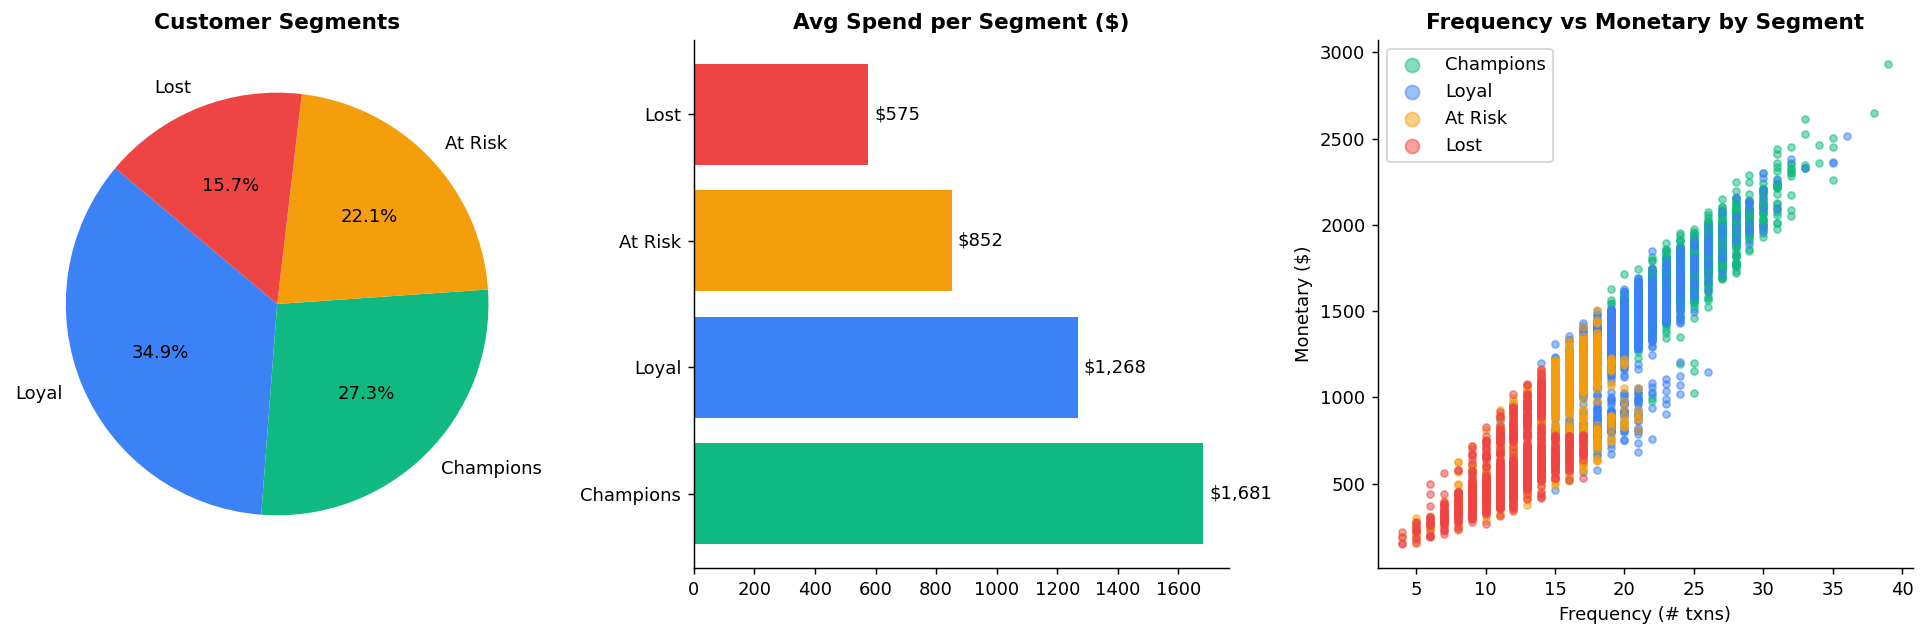

In [12]:
# ── RFM Visualisation ─────────────────────────────────────────────────────
COLORS = {'Champions':'#10B981','Loyal':'#3B82F6','At Risk':'#F59E0B','Lost':'#EF4444'}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Segment counts
seg_counts = rfm['Segment'].value_counts()
axes[0].pie(seg_counts, labels=seg_counts.index, autopct='%1.1f%%',
            colors=[COLORS[s] for s in seg_counts.index], startangle=140)
axes[0].set_title('Customer Segments', fontweight='bold')

# Avg monetary per segment
seg_order = ['Champions','Loyal','At Risk','Lost']
seg_avg = rfm.groupby('Segment')['monetary'].mean().reindex(seg_order)
bars = axes[1].barh(seg_order, seg_avg, color=[COLORS[s] for s in seg_order])
axes[1].set_title('Avg Spend per Segment ($)', fontweight='bold')
for bar, val in zip(bars, seg_avg):
    axes[1].text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
                 f'${val:,.0f}', va='center')

# RFM scatter: Frequency vs Monetary coloured by segment
for seg in seg_order:
    sub = rfm[rfm['Segment'] == seg]
    axes[2].scatter(sub['frequency'], sub['monetary'], label=seg,
                    color=COLORS[seg], alpha=0.5, s=15)
axes[2].set_title('Frequency vs Monetary by Segment', fontweight='bold')
axes[2].set_xlabel('Frequency (# txns)')
axes[2].set_ylabel('Monetary ($)')
axes[2].legend(markerscale=2)

plt.tight_layout()
plt.savefig('../reports/charts/customer_segments.png', bbox_inches='tight')
plt.show()


## 3.4  Time-Series & Trend Analysis

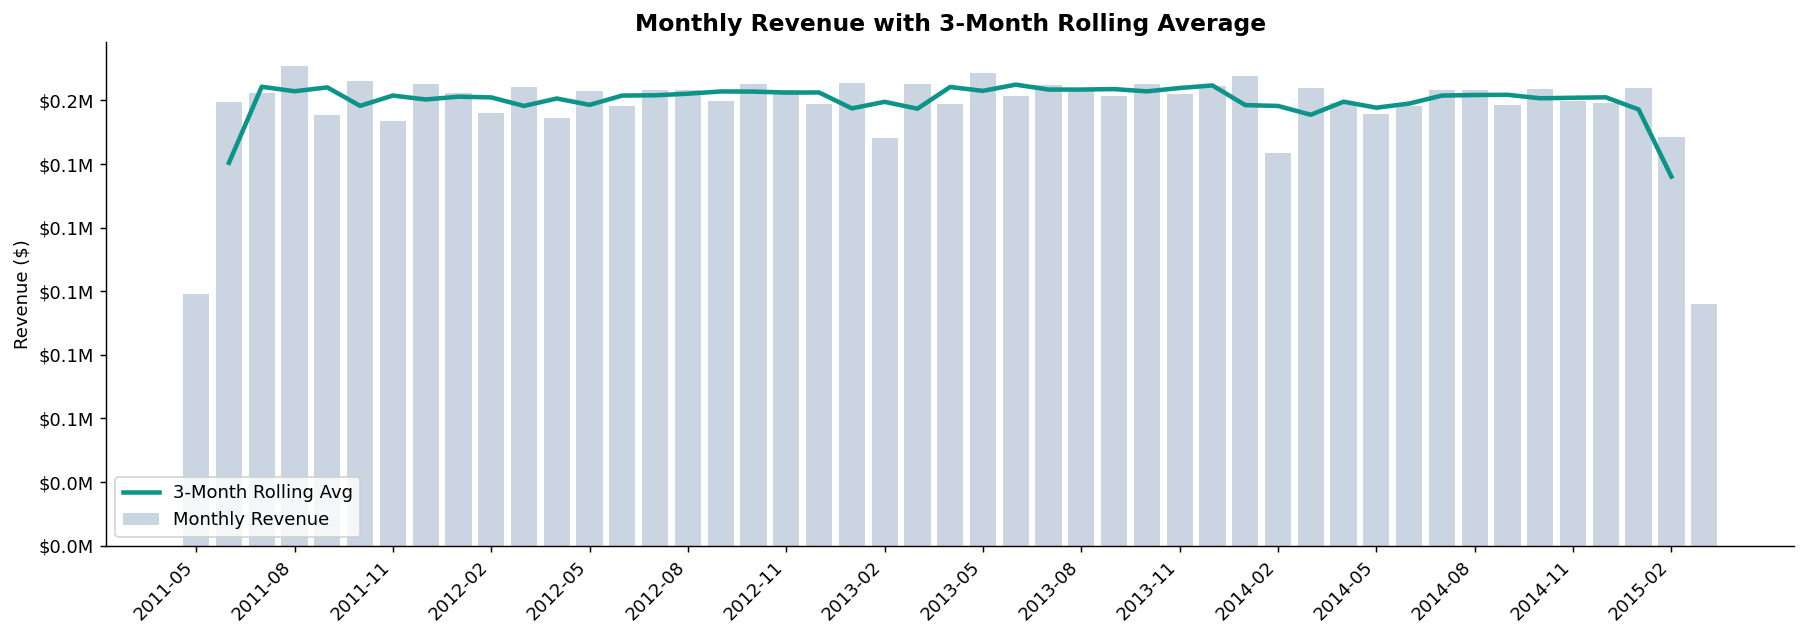

Top 3 Revenue Months:
 ym_str  revenue
2011-08   188605
2013-05   185826
2014-01   184554


In [14]:
# ── Monthly revenue ───────────────────────────────────────────────────────
df['year_month'] = df['trans_date'].dt.to_period('M')
monthly = df.groupby('year_month').agg(
    revenue = ('tran_amount', 'sum'),
    txns    = ('tran_amount', 'count')
).reset_index()
monthly['ym_str']  = monthly['year_month'].astype(str)
monthly['rolling3'] = monthly['revenue'].rolling(3, center=True).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(monthly['ym_str'], monthly['revenue'], color='#CBD5E1', label='Monthly Revenue')
ax.plot(monthly['ym_str'], monthly['rolling3'], color='#0D9488', linewidth=2.5,
        label='3-Month Rolling Avg')
ax.set_title('Monthly Revenue with 3-Month Rolling Average', fontsize=13, fontweight='bold')
ax.set_ylabel('Revenue ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e6:.1f}M'))
step = max(1, len(monthly)//12)
ax.set_xticks(range(0, len(monthly), step))
ax.set_xticklabels(monthly['ym_str'][::step], rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/charts/top_3_months.png', bbox_inches='tight')
plt.show()

top3 = monthly.nlargest(3, 'revenue')[['ym_str','revenue']]
print("Top 3 Revenue Months:")
print(top3.to_string(index=False))


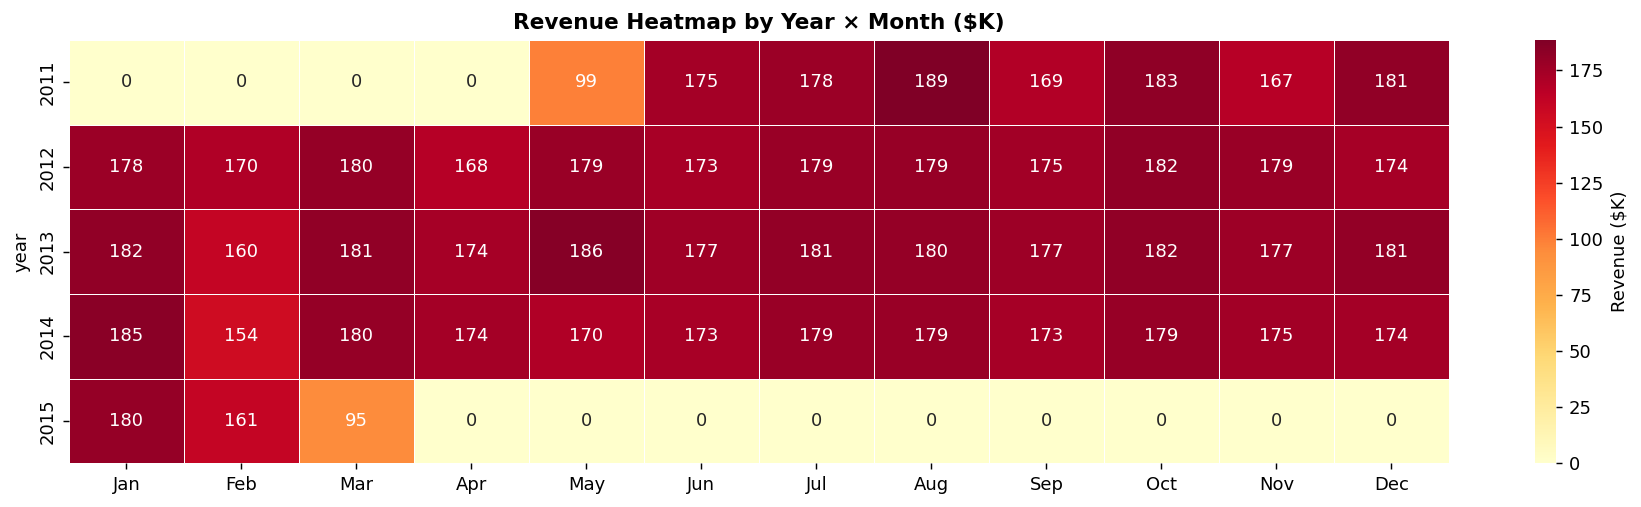

In [16]:
# ── Seasonality heatmap ───────────────────────────────────────────────────
df['year']  = df['trans_date'].dt.year
df['month'] = df['trans_date'].dt.month

pivot = df.pivot_table(values='tran_amount', index='year', columns='month',
                       aggfunc='sum', fill_value=0)
pivot.columns = ['Jan','Feb','Mar','Apr','May','Jun',
                 'Jul','Aug','Sep','Oct','Nov','Dec'][:len(pivot.columns)]

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(pivot/1e3, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label':'Revenue ($K)'})
ax.set_title('Revenue Heatmap by Year × Month ($K)', fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/charts/seasonality_heatmap.png', bbox_inches='tight')
plt.show()


## 3.5  Cohort Retention Analysis

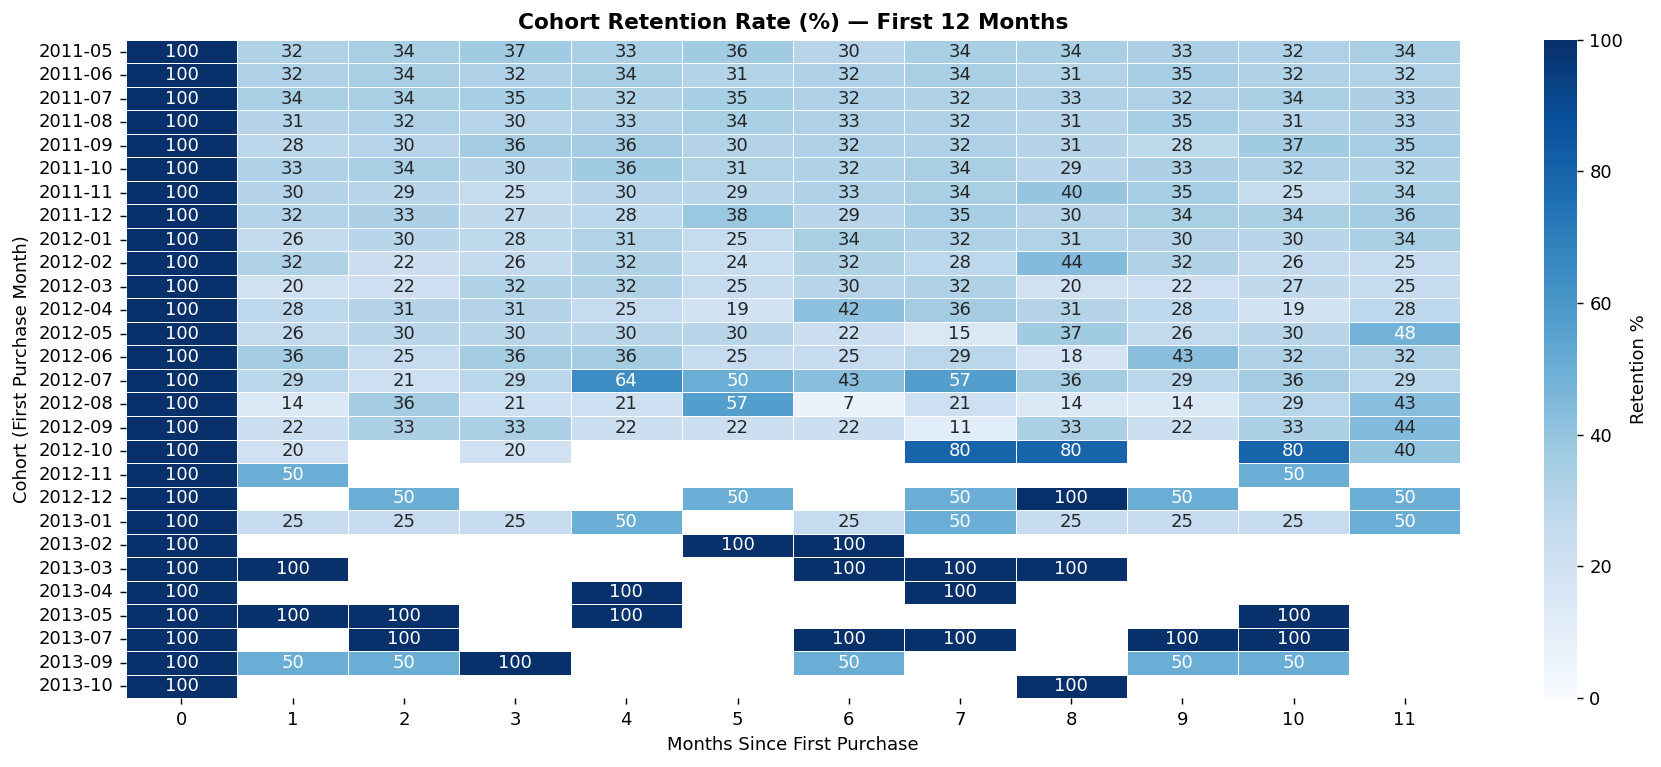

In [18]:
# ── Build cohort table ────────────────────────────────────────────────────
df['cohort_month'] = df.groupby('customer_id')['trans_date']                        .transform('min').dt.to_period('M')
df['period_number'] = (df['year_month'] - df['cohort_month']).apply(lambda x: x.n)

cohort_data = df.groupby(['cohort_month','period_number'])['customer_id']                 .nunique().reset_index()
cohort_data.columns = ['cohort_month','period_number','customers']

cohort_pivot = cohort_data.pivot_table(index='cohort_month',
                                       columns='period_number',
                                       values='customers')
cohort_size  = cohort_pivot.iloc[:, 0]
retention    = cohort_pivot.divide(cohort_size, axis=0).round(3) * 100

# Show first 12 periods only
retention_plot = retention.iloc[:, :12]

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(retention_plot, annot=True, fmt='.0f', cmap='Blues',
            linewidths=0.5, ax=ax, vmin=0, vmax=100,
            cbar_kws={'label': 'Retention %'})
ax.set_title('Cohort Retention Rate (%) — First 12 Months', fontweight='bold')
ax.set_xlabel('Months Since First Purchase')
ax.set_ylabel('Cohort (First Purchase Month)')
plt.tight_layout()
plt.savefig('../reports/charts/cohort_retention.png', bbox_inches='tight')
plt.show()


## 3.6  Response Rate Deep-Dive

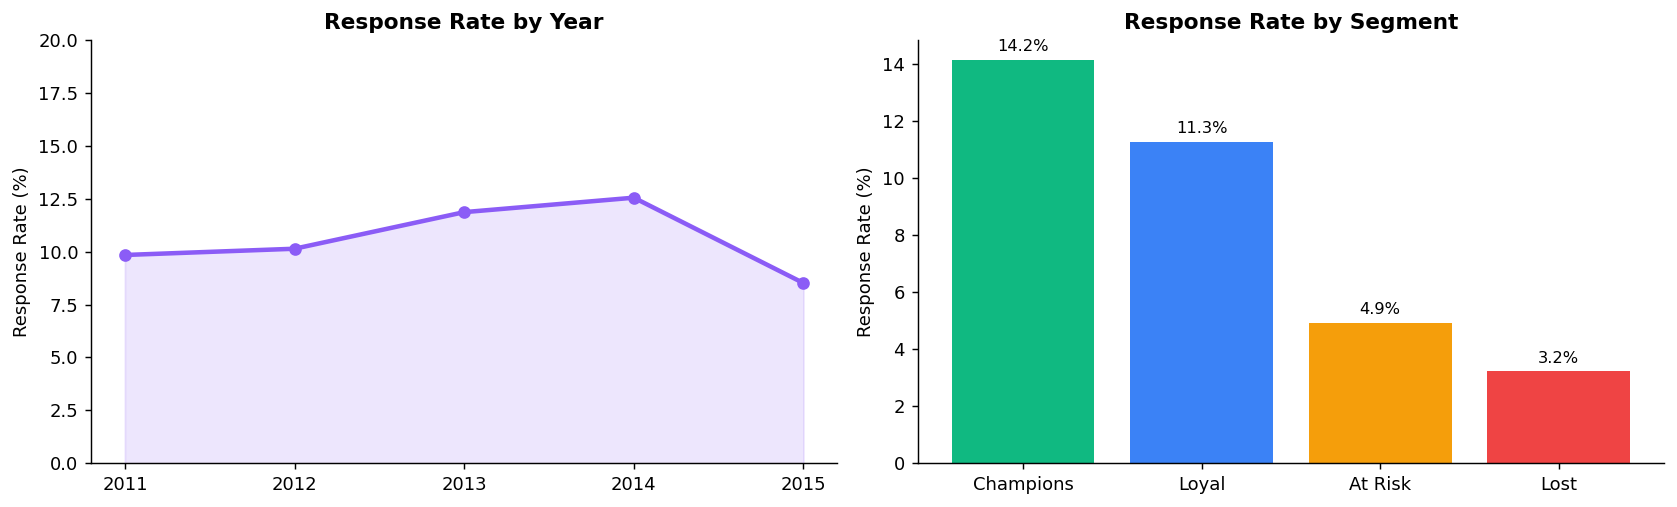

In [19]:
# ── Response rate by year ─────────────────────────────────────────────────
resp_year = df.groupby('year')['response'].mean().mul(100).reset_index()
resp_year.columns = ['Year','Response Rate (%)']

# ── Response by spend tier ────────────────────────────────────────────────
rfm_resp = rfm[['customer_id','Segment','monetary']].merge(
    df[['customer_id','response']].drop_duplicates('customer_id'),
    on='customer_id', how='left')

resp_seg = rfm_resp.groupby('Segment')['response'].mean().mul(100).reset_index()
resp_seg.columns = ['Segment','Response Rate (%)']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(resp_year['Year'].astype(str), resp_year['Response Rate (%)'],
             marker='o', linewidth=2.5, color='#8B5CF6')
axes[0].fill_between(resp_year['Year'].astype(str), resp_year['Response Rate (%)'],
                     alpha=0.15, color='#8B5CF6')
axes[0].set_title('Response Rate by Year', fontweight='bold')
axes[0].set_ylabel('Response Rate (%)')
axes[0].set_ylim(0, 20)

seg_order = ['Champions','Loyal','At Risk','Lost']
resp_seg = resp_seg.set_index('Segment').reindex(seg_order).reset_index()
bars = axes[1].bar(resp_seg['Segment'], resp_seg['Response Rate (%)'],
                   color=[COLORS.get(s,'grey') for s in resp_seg['Segment']])
axes[1].set_title('Response Rate by Segment', fontweight='bold')
axes[1].set_ylabel('Response Rate (%)')
for bar, val in zip(bars, resp_seg['Response Rate (%)']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../reports/charts/churn_distribution.png', bbox_inches='tight')
plt.show()


In [20]:
# ── Avg spend: responders vs non-responders ───────────────────────────────
spend_resp = df.groupby('response')['tran_amount'].agg(['mean','sum','count'])
spend_resp.index = ['Non-Responder','Responder']
spend_resp.columns = ['Avg Transaction ($)','Total Revenue ($)','Transactions']
spend_resp = spend_resp.round(2)
print(spend_resp)


               Avg Transaction ($)  Total Revenue ($)  Transactions
Non-Responder                64.49            7166830        111127
Responder                    69.03             955548         13842


## 3.7  Key Insights & Recommendations

In [21]:
total_rev   = df['tran_amount'].sum()
champions   = (rfm['Segment']=='Champions').sum()
at_risk     = (rfm['Segment']=='At Risk').sum()
resp_rate   = df['response'].mean()*100
top_month   = monthly.loc[monthly['revenue'].idxmax(), 'ym_str']

print("=" * 58)
print("   📊  RETAIL SALES ANALYTICS — KEY INSIGHTS")
print("=" * 58)
print(f"  Total Revenue       : ${total_rev:>12,.0f}")
print(f"  Total Customers     : {df['customer_id'].nunique():>12,}")
print(f"  Champion Customers  : {champions:>12,}")
print(f"  At-Risk Customers   : {at_risk:>12,}")
print(f"  Campaign Response % : {resp_rate:>11.1f}%")
print(f"  Best Revenue Month  : {top_month:>12}")
print("=" * 58)
print()
print("📌 RECOMMENDATIONS")
print()
print("  1. RETENTION  — Launch win-back campaign for 'At Risk'")
print("     customers. They have history; a targeted 10% discount")
print("     email could recover significant revenue.")
print()
print("  2. LOYALTY    — Reward 'Champions' with early access,")
print("     loyalty points, or exclusive offers to sustain spend.")
print()
print("  3. MARKETING  — Response rate is ~11%. Segment campaigns:")
print("     Champions → VIP offers | At Risk → discount nudge |")
print("     Lost → re-engagement series.")
print()
print("  4. SEASONALITY — Revenue peaks in specific months.")
print("     Pre-load inventory and run promotions 2 weeks before")
print("     peak months to maximize capture.")
print()
print("  5. UPSELL     — Avg txn is ~$65. A 'Buy 2 Get 10% Off'")
print("     promotion could push avg to $72+, lifting revenue ~10%.")


   📊  RETAIL SALES ANALYTICS — KEY INSIGHTS
  Total Revenue       : $   8,122,378
  Total Customers     :        6,884
  Champion Customers  :        1,879
  At-Risk Customers   :        1,518
  Campaign Response % :        11.1%
  Best Revenue Month  :      2011-08

📌 RECOMMENDATIONS

  1. RETENTION  — Launch win-back campaign for 'At Risk'
     customers. They have history; a targeted 10% discount
     email could recover significant revenue.

  2. LOYALTY    — Reward 'Champions' with early access,
     loyalty points, or exclusive offers to sustain spend.

  3. MARKETING  — Response rate is ~11%. Segment campaigns:
     Champions → VIP offers | At Risk → discount nudge |
     Lost → re-engagement series.

  4. SEASONALITY — Revenue peaks in specific months.
     Pre-load inventory and run promotions 2 weeks before
     peak months to maximize capture.

  5. UPSELL     — Avg txn is ~$65. A 'Buy 2 Get 10% Off'
     promotion could push avg to $72+, lifting revenue ~10%.
